# Stage 1: MIL Binary Anomaly Gate
## XVAD Pipeline — New Direction (LLM + RAG)

---

### What This Notebook Does
This is **Stage 1** of your new 3-stage pipeline. It reuses your trained MIL model (96.49% AUC) as a fast binary gate:
- Loads `best_model.pth` (your 62-epoch trained model)
- Runs inference on pre-extracted `.npy` TimeSformer features
- Returns: anomaly score, segment scores, anomaly segments, peak segment
- Only anomalous clips pass to Stage 2 (VLM Captioning)

---

### Pipeline Position
```
Stage 1: MIL Binary Gate        ◀ YOU ARE HERE
Stage 2: Smart Frame Extraction + VLM Captioning
Stage 3: RAG + LLM Classification & Explanation
```

---

### Your Paths
```
Models   : C:\2014741\MIL_Models\best_model.pth
Features : C:\2014741\TimeSformer_Features\<class>\<video>.npy
Videos   : C:\2014741\Raw_Videos_Unified
```

---
## Section 1: Imports & Configuration
---

In [4]:
"""
Stage 1: Imports and Configuration
All paths are set to your local machine.
"""

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
from typing import Dict, List, Optional
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
#  YOUR PATHS — edit only if needed
# ─────────────────────────────────────────────
MODEL_PATH    = r"C:\2014741\MIL_Models\best_model.pth"
FEATURES_ROOT = r"C:\2014741\TimeSformer_Features"
VIDEOS_ROOT   = r"C:\2014741\Raw_Videos_Unified"

# ─────────────────────────────────────────────
#  MODEL PARAMS — must match Phase 3 training
# ─────────────────────────────────────────────
FEATURE_DIM       = 768
HIDDEN_DIM_1      = 512
HIDDEN_DIM_2      = 128
DROPOUT_RATE      = 0.6
TOP_K             = 3
NUM_SEGMENTS      = 16
ANOMALY_THRESHOLD = 0.5
SMOOTHING_SIGMA   = 2

# ─────────────────────────────────────────────
#  DEVICE
# ─────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("STAGE 1 — MIL BINARY ANOMALY GATE")
print("=" * 60)
print(f"  Device     : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU        : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"  Model path : {MODEL_PATH}")
print(f"  Features   : {FEATURES_ROOT}")
print(f"  Model exists: {os.path.exists(MODEL_PATH)}")
print("=" * 60)

STAGE 1 — MIL BINARY ANOMALY GATE
  Device     : cpu
  Model path : C:\2014741\MIL_Models\best_model.pth
  Features   : C:\2014741\TimeSformer_Features
  Model exists: True


---
## Section 2: MIL Network Architecture
Exact copy from your Phase 4B notebook.

---

In [6]:
"""
MIL Network — exact architecture from Phase 4B.
Architecture: 768 → 512 → 128 → 1
Top-K pooling: k=3 over 16 segments.
"""

class MILNetwork(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, hidden_dim_1=HIDDEN_DIM_1,
                 hidden_dim_2=HIDDEN_DIM_2, dropout_rate=DROPOUT_RATE, top_k=TOP_K):
        super().__init__()
        self.top_k   = top_k
        self.fc1     = nn.Linear(feature_dim, hidden_dim_1)
        self.fc2     = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.fc3     = nn.Linear(hidden_dim_2, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        """
        x: (batch, num_segments, feature_dim)
        returns: (video_scores, segment_scores)
        """
        batch_size, num_segments, _ = x.shape
        x = x.view(-1, x.shape[-1])

        x = F.relu(self.fc1(x)); x = self.dropout(x)
        x = F.relu(self.fc2(x)); x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))

        segment_scores = x.view(batch_size, num_segments)
        topk_scores, _ = torch.topk(segment_scores, k=self.top_k, dim=1)
        video_scores   = topk_scores.mean(dim=1)

        return video_scores, segment_scores


print("✅ MILNetwork architecture defined!")
print(f"   Architecture : {FEATURE_DIM} → {HIDDEN_DIM_1} → {HIDDEN_DIM_2} → 1")
print(f"   Top-K        : {TOP_K}")
print(f"   Num segments : {NUM_SEGMENTS}")

✅ MILNetwork architecture defined!
   Architecture : 768 → 512 → 128 → 1
   Top-K        : 3
   Num segments : 16


---
## Section 3: Load Trained Model
---

In [7]:
"""
Load best_model.pth — your 96.49% AUC trained model.
"""

def load_mil_model(model_path: str = MODEL_PATH) -> nn.Module:
    """Load trained MIL weights and return model in eval mode."""
    print("=" * 60)
    print("LOADING MIL MODEL")
    print("=" * 60)

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"\n❌ Model not found: {model_path}")

    model      = MILNetwork().to(DEVICE)
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        print(f"  Best epoch : {checkpoint.get('epoch', 'N/A')}")
        if "val_auc" in checkpoint:
            print(f"  Val AUC    : {checkpoint['val_auc']:.4f}")
    else:
        model.load_state_dict(checkpoint)

    model.eval()
    params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters : {params:,}")
    print(f"  Device     : {DEVICE}")
    print(f"  Status     : eval mode (frozen)")
    print("=" * 60)
    return model


# Load the model
model = load_mil_model()

LOADING MIL MODEL
  Best epoch : 62
  Val AUC    : 0.9527
  Parameters : 459,521
  Device     : cpu
  Status     : eval mode (frozen)


---
## Section 4: Core Inference Function
---

In [8]:
"""
Core inference function — takes a .npy feature file,
returns anomaly score, segment scores, and key segments.
"""

def run_mil_inference(npy_path: str, model: nn.Module) -> Dict:
    """
    Run MIL inference on a pre-extracted .npy feature file.

    Args:
        npy_path : Path to .npy file — shape (num_clips, 768)
        model    : Loaded MILNetwork in eval mode

    Returns dict:
        video_score      : float  — overall anomaly probability [0-1]
        is_anomaly       : bool   — True if score > 0.5
        segment_scores   : list   — raw scores for 16 segments
        smoothed_scores  : list   — Gaussian-smoothed scores
        anomaly_segments : list   — segment indices above threshold
        peak_segment     : int    — index of highest-scoring segment
        num_clips        : int    — total clips in original video
    """
    if not os.path.exists(npy_path):
        raise FileNotFoundError(f"Features not found: {npy_path}")

    # Load (num_clips, 768)
    features  = np.load(npy_path)
    num_clips = features.shape[0]

    # Sample 16 segments evenly — same as Phase 4B
    indices = np.linspace(0, num_clips - 1, NUM_SEGMENTS, dtype=int)
    sampled = features[indices]                                     # (16, 768)
    tensor  = torch.FloatTensor(sampled).unsqueeze(0).to(DEVICE)   # (1, 16, 768)

    with torch.no_grad():
        video_score, segment_scores = model(tensor)

    video_score   = video_score.item()
    seg_scores_np = segment_scores.squeeze().cpu().numpy()          # (16,)
    smoothed      = gaussian_filter1d(seg_scores_np, sigma=SMOOTHING_SIGMA)
    anomaly_segs  = np.where(smoothed > ANOMALY_THRESHOLD)[0].tolist()
    peak_segment  = int(np.argmax(smoothed))

    return {
        "video_score"      : round(video_score, 4),
        "is_anomaly"       : video_score > ANOMALY_THRESHOLD,
        "segment_scores"   : seg_scores_np.tolist(),
        "smoothed_scores"  : smoothed.tolist(),
        "anomaly_segments" : anomaly_segs,
        "peak_segment"     : peak_segment,
        "num_clips"        : num_clips,
    }


def find_npy_path(video_name: str, features_root: str = FEATURES_ROOT) -> Optional[str]:
    """
    Search for <video_name>.npy anywhere under features_root.
    Works with or without file extension.
    """
    stem = Path(video_name).stem
    for root, _, files in os.walk(features_root):
        for f in files:
            if f == f"{stem}.npy":
                return os.path.join(root, f)
    return None


print("✅ run_mil_inference() defined")
print("✅ find_npy_path() defined")

✅ run_mil_inference() defined
✅ find_npy_path() defined


---
## Section 5: Test on Single Video
Run inference on one anomaly video to verify everything works.

---

In [12]:
"""
Test Stage 1 on a single video.
Change the video name below to any video you want to test.
"""

# ── Change this to any video name from your dataset ──
TEST_VIDEO = "Fighting020_x264"

# Find the .npy file
npy_path = find_npy_path(TEST_VIDEO)

if npy_path is None:
    print(f"❌ Could not find .npy for: {TEST_VIDEO}")
    print(f"   Searching in: {FEATURES_ROOT}")
    print("   Check the exact filename with:")
    print(f"   import os; print(os.listdir(r'C:\\2014741\\TimeSformer_Features\\Fighting'))")
else:
    print(f"✅ Found: {npy_path}")

    # Run inference
    result = run_mil_inference(npy_path, model)

    # Print results
    print("\n" + "=" * 60)
    print(f"RESULT: {TEST_VIDEO}")
    print("=" * 60)
    status = "🔴 ANOMALY" if result['is_anomaly'] else "🟢 NORMAL"
    print(f"  Decision         : {status}")
    print(f"  Video score      : {result['video_score']}")
    print(f"  Peak segment     : {result['peak_segment']}  (out of 16)")
    print(f"  Anomaly segments : {result['anomaly_segments']}")
    print(f"  Total clips      : {result['num_clips']}")

    # Visual bar chart of segment scores
    print("\n  Smoothed segment scores:")
    print("  " + "-" * 50)
    for i, s in enumerate(result['smoothed_scores']):
        bar    = "█" * int(s * 30)
        marker = " ← PEAK" if i == result['peak_segment'] else ""
        alert  = " ⚠️" if i in result['anomaly_segments'] else ""
        print(f"  Seg {i:02d}: {s:.3f}  {bar}{marker}{alert}")
    print("  " + "-" * 50)

✅ Found: C:\2014741\TimeSformer_Features\Fighting\Fighting020_x264.npy

RESULT: Fighting020_x264
  Decision         : 🔴 ANOMALY
  Video score      : 0.9964
  Peak segment     : 3  (out of 16)
  Anomaly segments : [0, 1, 2, 3, 4, 5, 6]
  Total clips      : 34

  Smoothed segment scores:
  --------------------------------------------------
  Seg 00: 0.590  █████████████████ ⚠️
  Seg 01: 0.658  ███████████████████ ⚠️
  Seg 02: 0.744  ██████████████████████ ⚠️
  Seg 03: 0.792  ███████████████████████ ← PEAK ⚠️
  Seg 04: 0.772  ███████████████████████ ⚠️
  Seg 05: 0.685  ████████████████████ ⚠️
  Seg 06: 0.551  ████████████████ ⚠️
  Seg 07: 0.397  ███████████
  Seg 08: 0.258  ███████
  Seg 09: 0.153  ████
  Seg 10: 0.088  ██
  Seg 11: 0.053  █
  Seg 12: 0.036  █
  Seg 13: 0.027  
  Seg 14: 0.021  
  Seg 15: 0.017  
  --------------------------------------------------


---
## Section 6: Batch Inference on Multiple Videos
Test on several videos across different classes.

---

In [9]:
"""
Batch inference — run on multiple videos at once.
Update the list below with videos from your dataset.
"""

def batch_inference(video_names: List[str], model: nn.Module) -> List[Dict]:
    """Run inference on a list of video names. Returns list of result dicts."""
    results   = []
    not_found = []

    print("=" * 60)
    print("BATCH INFERENCE")
    print("=" * 60)

    for vname in video_names:
        npy_path = find_npy_path(vname)
        if npy_path is None:
            print(f"  ⚠️  Not found : {vname}")
            not_found.append(vname)
            continue

        result              = run_mil_inference(npy_path, model)
        result["video_name"] = vname
        results.append(result)

        status = "🔴 ANOMALY" if result['is_anomaly'] else "🟢 NORMAL "
        print(f"  {status}  {vname:<40}  score={result['video_score']:.4f}  "
              f"peak_seg={result['peak_segment']}")

    print("=" * 60)
    print(f"  Total processed : {len(results)}")
    print(f"  Not found       : {len(not_found)}")
    anomalies = sum(1 for r in results if r['is_anomaly'])
    print(f"  Anomalies found : {anomalies} / {len(results)}")
    return results


# ── Test videos — one from each class ──
# Update these names based on what you have in your dataset
test_videos = [
    "Fighting015_x264",
    "Explosion009_x264",
    "Robbery014_x264",
    "Shooting011_x264",
    "Stealing020_x264",
]

batch_results = batch_inference(test_videos, model)

BATCH INFERENCE
  🔴 ANOMALY  Fighting015_x264                          score=0.9998  peak_seg=15
  🔴 ANOMALY  Explosion009_x264                         score=1.0000  peak_seg=15
  🟢 NORMAL   Robbery014_x264                           score=0.4158  peak_seg=8
  🔴 ANOMALY  Shooting011_x264                          score=0.9977  peak_seg=15
  🔴 ANOMALY  Stealing020_x264                          score=0.9995  peak_seg=6
  Total processed : 5
  Not found       : 0
  Anomalies found : 4 / 5


---
## Section 7: Visualize Segment Scores
Plot the anomaly heatmap for any video.

---

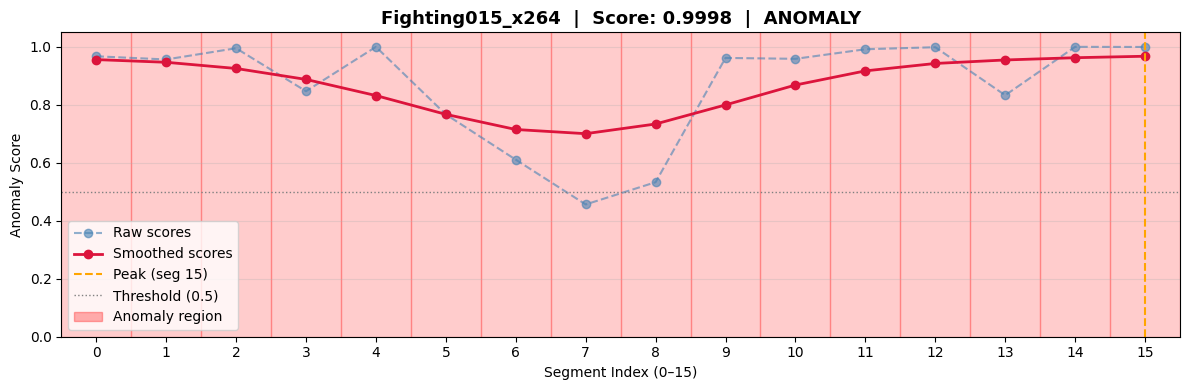

  Peak segment    : 15
  Anomaly segments: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  → Stage 2 will extract frames from these segments


In [10]:
"""
Visualize segment-level anomaly scores for a video.
"""

from typing import Dict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_segment_scores(result: Dict, video_name: str = ""):
    """Plot raw vs smoothed segment scores with anomaly regions highlighted."""
    fig, ax = plt.subplots(figsize=(12, 4))

    segments = list(range(NUM_SEGMENTS))
    raw      = result['segment_scores']
    smoothed = result['smoothed_scores']
    anomaly  = result['anomaly_segments']
    peak     = result['peak_segment']

    # Highlight anomaly regions
    for seg in anomaly:
        ax.axvspan(seg - 0.5, seg + 0.5, alpha=0.2, color='red', label='_nolegend_')

    # Plot scores
    ax.plot(segments, raw,      'o--', color='steelblue', alpha=0.6, label='Raw scores')
    ax.plot(segments, smoothed, 'o-',  color='crimson',  linewidth=2, label='Smoothed scores')

    # Peak marker
    ax.axvline(x=peak, color='orange', linestyle='--', linewidth=1.5, label=f'Peak (seg {peak})')

    # Threshold line
    ax.axhline(y=ANOMALY_THRESHOLD, color='gray', linestyle=':', linewidth=1, label='Threshold (0.5)')

    # Labels
    status = "ANOMALY" if result['is_anomaly'] else "NORMAL"
    title  = f"{video_name}  |  Score: {result['video_score']}  |  {status}"
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Segment Index (0–15)")
    ax.set_ylabel("Anomaly Score")
    ax.set_xlim(-0.5, NUM_SEGMENTS - 0.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(segments)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    red_patch = mpatches.Patch(color='red', alpha=0.3, label='Anomaly region')
    ax.legend(handles=ax.get_legend_handles_labels()[0] + [red_patch])

    plt.tight_layout()
    plt.show()
    print(f"  Peak segment    : {peak}")
    print(f"  Anomaly segments: {anomaly}")
    print(f"  → Stage 2 will extract frames from these segments")


# Plot the first batch result
if batch_results:
    plot_segment_scores(batch_results[0], batch_results[0]['video_name'])

---
## Section 8: Stage 1 Output Format
This is what Stage 2 will receive for every anomalous clip.

---

In [11]:
"""
Show what Stage 1 passes to Stage 2.
Stage 2 will use: video_name, anomaly_segments, peak_segment
to extract the right frames for VLM captioning.
"""

import json

if batch_results:
    # Filter only anomalous videos — only these go to Stage 2
    anomalous = [r for r in batch_results if r['is_anomaly']]
    normal    = [r for r in batch_results if not r['is_anomaly']]

    print("=" * 60)
    print("STAGE 1 → STAGE 2 HANDOFF")
    print("=" * 60)
    print(f"  Total videos    : {len(batch_results)}")
    print(f"  🔴 Anomalous    : {len(anomalous)}  → pass to Stage 2")
    print(f"  🟢 Normal       : {len(normal)}   → discard (no LLM cost)")

    print("\n  Stage 2 will receive:")
    for r in anomalous:
        stage2_input = {
            "video_name"      : r['video_name'],
            "video_score"     : r['video_score'],
            "anomaly_segments": r['anomaly_segments'],
            "peak_segment"    : r['peak_segment'],
            "num_clips"       : r['num_clips'],
        }
        print(f"\n  {r['video_name']}:")
        print(json.dumps(stage2_input, indent=4))

print("\n" + "=" * 60)
print("✅ Stage 1 COMPLETE")
print("   Next: Stage 2 — Smart Frame Extraction + VLM Captioning")
print("=" * 60)

STAGE 1 → STAGE 2 HANDOFF
  Total videos    : 5
  🔴 Anomalous    : 4  → pass to Stage 2
  🟢 Normal       : 1   → discard (no LLM cost)

  Stage 2 will receive:

  Fighting015_x264:
{
    "video_name": "Fighting015_x264",
    "video_score": 0.9998,
    "anomaly_segments": [
        0,
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15
    ],
    "peak_segment": 15,
    "num_clips": 154
}

  Explosion009_x264:
{
    "video_name": "Explosion009_x264",
    "video_score": 1.0,
    "anomaly_segments": [
        0,
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15
    ],
    "peak_segment": 15,
    "num_clips": 17
}

  Shooting011_x264:
{
    "video_name": "Shooting011_x264",
    "video_score": 0.9977,
    "anomaly_segments": [
        8,
        9,
        